# 06 · Reported numbers

This notebook reproduces every number in the paper that notebooks 01–05 do not print, and draws Figures 1–3.

1. Run notebooks 01–05 first. This notebook reads the files they write to the repository root (listed in cell B0).
2. Run every cell top to bottom. Each check prints `MATCH` or `MISMATCH` against the value reported in the paper.
3. Cell B10 prints a `CHECK SUMMARY` and the package versions of this runtime.

Cells B3 and B5 refit a forest and take a few minutes. Cell C1 is an optional robustness run and is switched off by default.

In [3]:
   !pip install -q econml==0.17.0 dowhy==0.14 shap==0.52.0 joblib==1.5.3
   from google.colab import files
   up = files.upload()
   import zipfile, glob, os
   for name in up:
       if name.endswith('.zip'):
           zipfile.ZipFile(f'/content/{name}').extractall('/content/tmp')
   src = os.path.dirname(glob.glob('/content/tmp/**/oulad_full_corpus.csv', recursive=True)[0])
   os.system(f'cp -r "{src}"/. /content/')
   rsrc = os.path.dirname(glob.glob('/content/tmp/**/studentVle.csv', recursive=True)[0])
   os.makedirs('/content/raw', exist_ok=True); os.system(f'cp "{rsrc}"/*.csv /content/raw/')
   for n in up:
       if n.startswith('requirements'): os.replace(f'/content/{n}', '/content/requirements.txt')
   print('ready:', os.path.exists('/content/refutation_checkpoints/A_bootstrap.json'), os.path.exists('/content/raw/studentVle.csv'))

Saving causal_results.zip to causal_results (1).zip
Saving raw.zip to raw.zip
Saving requirements.txt to requirements (1).txt
ready: True True


In [4]:
# B0  Setup. Loads the canonical model and the files written by notebooks 01-05.
import os, math, json
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from econml.dml import CausalForestDML, LinearDML
from sklearn.ensemble import HistGradientBoostingRegressor

root = Path.cwd()
for p in [root, *root.parents]:
    if (p / "raw").is_dir():
        root = p
        break
BASE = str(root)

SEED = 42
N_TREES = 500
CANONICAL_ATE = 0.004786482048864249
CONFOUNDERS_V2 = ['region', 'imd_band', 'highest_education', 'age_band', 'gender',
                  'disability', 'code_presentation', 'num_of_prev_attempts',
                  'studied_credits', 'code_module']
CATEGORICAL_V2 = [c for c in CONFOUNDERS_V2 if c not in ('num_of_prev_attempts', 'studied_credits')]

NEEDED = ['refutation_checkpoints/A_bootstrap.json', 'oulad_full_corpus.csv', 'oulad_ouelluminate_subsample.csv', 'cf_canonical_model.pkl',
          'ddd_seed_sweep.csv', 'ihdp_per_realisation.csv', 'ablation_results_v2.csv',
          'logo_cv_results_v2.csv', 'sensitivity_sd_units.csv']
missing = [f for f in NEEDED if not os.path.exists(f'{BASE}/{f}')]
assert not missing, f'run notebooks 01-05 first; missing: {missing}'

full = pd.read_csv(f'{BASE}/oulad_full_corpus.csv')
full['imd_band'] = full['imd_band'].fillna('Missing')
X = pd.get_dummies(full[CONFOUNDERS_V2], columns=CATEGORICAL_V2, drop_first=True).astype(float)
T = full['oucontent_clicks'].to_numpy(dtype=float)
Y = full['performance_gain'].to_numpy(dtype=float)
assert X.shape == (17529, 40), f'shape drift: {X.shape}'

cf = joblib.load(f'{BASE}/cf_canonical_model.pkl')
ate = float(cf.ate(X))
assert abs(ate - CANONICAL_ATE) < 1e-6, f'not the canonical model: {ate!r}'
full['cate'] = cf.effect(X)
print(f'canonical ATE {ate!r}   n = {len(full):,}   X = {X.shape}')

CHECKS = []
def check(item, what, yours, paper, tol, where):
    yours = float(yours)
    ok = abs(yours - paper) <= tol
    CHECKS.append({'item': item, 'what': what, 'your_value': yours, 'paper': paper,
                   'tolerance': tol, 'status': 'MATCH' if ok else 'MISMATCH', 'where': where})
    print(f"{'MATCH   ' if ok else 'MISMATCH'}  {item}  {what}: yours {yours:.6g}   paper {paper:.6g}   ({where})")
    return ok

def make_cf(seed=SEED, leaf=50):
    return CausalForestDML(model_y=HistGradientBoostingRegressor(random_state=seed),
                           model_t=HistGradientBoostingRegressor(random_state=seed),
                           discrete_treatment=False, honest=True, min_samples_leaf=leaf,
                           n_estimators=N_TREES, cv=5, random_state=seed)

canonical ATE 0.004786482048864249   n = 17,529   X = (17529, 40)


### B1 · CCC half-width and Table 6
Paper: §5.5 half-width 0.003332; Table 6 required n of 1,214, 61,771 and 134,272; abstract "about 134,000".

Method: the 95% half-width of the CCC average effect from the canonical model. Required n is the sample at which that half-width would shrink to the target effect, assuming it falls with the square root of n: `n_required = n_CCC × (half-width / effect)²`. The target effects are read from your seed table, not typed in.

In [5]:
ccc = (full['code_module'] == 'CCC').to_numpy()
n_ccc = int(ccc.sum())
lo, hi = cf.ate_interval(X[ccc], alpha=0.05)
lo, hi = float(np.ravel(lo)[0]), float(np.ravel(hi)[0])
half_width = (hi - lo) / 2
print(f'CCC: n = {n_ccc:,}   ATE = {float(cf.ate(X[ccc]))!r}   95% CI [{lo!r}, {hi!r}]')
print(f'half-width = {half_width!r}')
check('Table 6', 'CCC 95% half-width', half_width, 0.003332, 5e-7, '§5.5, §6.4')

seed_tab = pd.read_csv(f'{BASE}/ddd_seed_sweep.csv', index_col=0)   # per-course CATE, seeds 42, 1, 7, 123
four_seed = seed_tab.mean(axis=1)
targets = [('smallest other-course estimate', four_seed.drop('CCC').min(), 1214),
           ('largest CCC value observed',     seed_tab.loc['CCC'].max(),   61771),
           ('CCC four-seed mean',             four_seed['CCC'],            134272)]
FULL_RELEASE = 32593
rows = []
for label, effect, paper_n in targets:
    n_req = math.ceil(n_ccc * (half_width / effect) ** 2)
    rows.append({'to resolve': label, 'effect': effect, 'required_n': n_req,
                 'against actual n': 'Achieved' if n_req <= n_ccc else f'{n_req / n_ccc:.1f}x short',
                 'against full release': f'{n_req / FULL_RELEASE:.1f}x'})
    check('Table 6', f'Table 6 required n, {label}', n_req, paper_n, 0, 'Table 6')
table6 = pd.DataFrame(rows)
print(table6.to_string(index=False))
table6.to_csv(f'{BASE}/table6_required_n.csv', index=False)
print(f'\nhalf-width / CCC four-seed mean = {half_width / four_seed["CCC"]:.2f}   (paper: "nearly eight times")')

CCC: n = 2,114   ATE = 0.00012948790139526208   95% CI [-0.0032022330011242917, 0.003461208803914815]
half-width = 0.0033317209025195533
MATCH     Table 6  CCC 95% half-width: yours 0.00333172   paper 0.003332   (§5.5, §6.4)
MATCH     Table 6  Table 6 required n, smallest other-course estimate: yours 1214   paper 1214   (Table 6)
MATCH     Table 6  Table 6 required n, largest CCC value observed: yours 61771   paper 61771   (Table 6)
MATCH     Table 6  Table 6 required n, CCC four-seed mean: yours 134272   paper 134272   (Table 6)
                    to resolve   effect  required_n against actual n against full release
smallest other-course estimate 0.004397        1214         Achieved                 0.0x
    largest CCC value observed 0.000616       61771      29.2x short                 1.9x
            CCC four-seed mean 0.000418      134272      63.5x short                 4.1x

half-width / CCC four-seed mean = 7.97   (paper: "nearly eight times")


### B2 · Between-course share of effect variance
Paper: abstract "three-quarters", §5.5 "75% ... within-course 25%". Method: the variance of the individual estimates splits exactly into a between-course part and a within-course part.

In [6]:
grand = full['cate'].mean()
by = full.groupby('code_module')['cate']
between = float((by.size() * (by.mean() - grand) ** 2).sum() / len(full))
total = float(full['cate'].var(ddof=0))
within = total - between
print(f'total {total:.4e}   between {between:.4e}   within {within:.4e}')
print(f'between share {between / total:.1%}   within share {within / total:.1%}')
check('§5.5', 'between-course share of CATE variance', between / total, 0.75, 0.005, 'abstract, §5.5, §6.2')

total 4.5338e-06   between 3.4009e-06   within 1.1329e-06
between share 75.0%   within share 25.0%
MATCH     §5.5  between-course share of CATE variance: yours 0.750117   paper 0.75   (abstract, §5.5, §6.2)


True

### B3 · Partial R² by confounder block, gender, and the 82% shift
Paper: §4.5 "about 85% of explained treatment variance and 67% of explained outcome variance", "moved the estimate by 82%", gender partial R² 0.000011. Figure 1: course identity 0.353 (T) / 0.086 (Y), presentation 0.017 / 0.005.

Method: least-squares fits of treatment and outcome on the forty columns, with and without each block. Partial R² = (RSS without block − RSS full) / RSS without block. "Share of explained" is printed two ways. §4.5 uses the first: the drop in R² when the block is removed, divided by the full R². The 82% shift refits the canonical forest without course identity, which is the pre-correction specification. **This cell takes a few minutes.**

In [7]:
BLOCKS = {'Socioeconomic context':      ['region', 'imd_band'],
          'Prior academic history':     ['highest_education', 'num_of_prev_attempts', 'studied_credits'],
          'Individual characteristics': ['gender', 'age_band', 'disability'],
          'Course-stage context':       ['code_presentation'],
          'Course identity':            ['code_module']}

def cols_of(vars_):
    return [c for c in X.columns if any(c == v or c.startswith(v + '_') for v in vars_)]

def rss(Z, y):
    Z1 = np.column_stack([np.ones(len(Z)), Z])
    beta, *_ = np.linalg.lstsq(Z1, y, rcond=None)
    r = y - Z1 @ beta
    return float(r @ r)

rows = []
for tname, y in [('T', T), ('Y', Y)]:
    tss = float(((y - y.mean()) ** 2).sum())
    rss_full = rss(X.to_numpy(), y)
    r2_full = 1 - rss_full / tss
    for block, vars_ in list(BLOCKS.items()) + [('gender alone', ['gender'])]:
        rss_red = rss(X.drop(columns=cols_of(vars_)).to_numpy(), y)
        rows.append({'block': block, 'target': tname, 'R2_full': r2_full,
                     'partial_R2': (rss_red - rss_full) / rss_red,
                     'share_drop': ((1 - rss_full / tss) - (1 - rss_red / tss)) / r2_full})
pr2 = pd.DataFrame(rows)
five = pr2[pr2['block'] != 'gender alone'].copy()
five['share_of_summed_partials'] = five['partial_R2'] / five.groupby('target')['partial_R2'].transform('sum')
pr2 = pr2.merge(five[['block', 'target', 'share_of_summed_partials']], on=['block', 'target'], how='left')
print(pr2.to_string(index=False, float_format=lambda v: f'{v:.6f}'))
pr2.to_csv(f'{BASE}/partial_r2_blocks.csv', index=False)

g = lambda b, t, col: float(pr2.loc[(pr2.block == b) & (pr2.target == t), col].iloc[0])
check('§4.5', 'course identity partial R-squared on treatment', g('Course identity', 'T', 'partial_R2'), 0.353, 5e-4, 'Figure 1')
check('§4.5', 'course identity partial R-squared on outcome',   g('Course identity', 'Y', 'partial_R2'), 0.086, 5e-4, 'Figure 1')
check('§4.5', 'presentation partial R-squared on treatment',    g('Course-stage context', 'T', 'partial_R2'), 0.017, 5e-4, 'Figure 1')
check('§4.5', 'presentation partial R-squared on outcome',      g('Course-stage context', 'Y', 'partial_R2'), 0.005, 5e-4, 'Figure 1')
check('§4.5', 'gender partial R-squared on outcome',            g('gender alone', 'Y', 'partial_R2'), 0.000011, 5e-7, '§4.5')
check('§4.5', 'course identity share of explained treatment variance', g('Course identity', 'T', 'share_drop'), 0.85, 0.05, '§4.5, Figure 1')
check('§4.5', 'course identity share of explained outcome variance',   g('Course identity', 'Y', 'share_drop'), 0.67, 0.05, '§4.5')

X_no_course = X.drop(columns=cols_of(['code_module']))
cf_nc = make_cf()
cf_nc.fit(Y, T, X=X_no_course)
ate_nc = float(cf_nc.ate(X_no_course))
print(f'\nATE without course identity ({X_no_course.shape[1]} columns): {ate_nc!r}')
print(f'ATE with course identity (canonical):            {ate!r}')
print(f'shift relative to the pre-correction estimate: {(ate - ate_nc) / abs(ate_nc):+.1%}')
print(f'shift relative to the corrected estimate:      {(ate - ate_nc) / abs(ate):+.1%}')
check('§4.5', 'shift when course identity is added (vs pre-correction)', abs(ate - ate_nc) / abs(ate_nc), 0.82, 0.005, '§4.5')

                     block target  R2_full  partial_R2  share_drop  share_of_summed_partials
     Socioeconomic context      T 0.391269    0.002980    0.004650                  0.007403
    Prior academic history      T 0.391269    0.008160    0.012799                  0.020271
Individual characteristics      T 0.391269    0.021071    0.033487                  0.052345
      Course-stage context      T 0.391269    0.017161    0.027165                  0.042632
           Course identity      T 0.391269    0.353160    0.849424                  0.877349
              gender alone      T 0.391269    0.002653    0.004138                       NaN
     Socioeconomic context      Y 0.122776    0.006250    0.044934                  0.061596
    Prior academic history      Y 0.122776    0.004010    0.028766                  0.039521
Individual characteristics      Y 0.122776    0.001160    0.008300                  0.011436
      Course-stage context      Y 0.122776    0.004519    0.032431    

True

### B4 · Gender Mann–Whitney test
Paper: §5.3 U = 30,683,318, p = 8.88 × 10⁻⁸², rank-biserial r = 0.170. The test runs on the forest's individual estimates, female group first. The printout also gives the direction in words, and §5.3 must say it (see the work order).

In [8]:
from scipy.stats import mannwhitneyu
f = full.loc[full['gender'] == 'F', 'cate'].to_numpy()
m = full.loc[full['gender'] == 'M', 'cate'].to_numpy()
res = mannwhitneyu(f, m, alternative='two-sided')
u_f = float(res.statistic)
pairs = len(f) * len(m)
r_rb = 1 - 2 * u_f / pairs
print(f'n_F = {len(f):,}   n_M = {len(m):,}   U_F = {u_f:,.0f}   U_M = {pairs - u_f:,.0f}   p = {res.pvalue:.3g}')
print(f'rank-biserial r = 1 - 2 U_F / (n_F n_M) = {r_rb:.3f}')
print(f'female estimate higher in {u_f / pairs:.1%} of female-male pairs')
check('§5.3', 'Mann-Whitney U, female group first', u_f, 30683318, 0.5, '§5.3')
log_p = math.log10(res.pvalue) if res.pvalue > 0 else float('-inf')   # p below 1e-308 prints as -inf
check('§5.3', 'log10 p', log_p, math.log10(8.88e-82), 0.005, '§5.3')
check('§5.3', 'rank-biserial r', r_rb, 0.170, 5e-4, '§5.3')

n_F = 7,074   n_M = 10,455   U_F = 30,683,318   U_M = 43,275,352   p = 8.88e-82
rank-biserial r = 1 - 2 U_F / (n_F n_M) = 0.170
female estimate higher in 41.5% of female-male pairs
MATCH     §5.3  Mann-Whitney U, female group first: yours 3.06833e+07   paper 3.06833e+07   (§5.3)
MATCH     §5.3  log10 p: yours -81.0518   paper -81.0516   (§5.3)
MATCH     §5.3  rank-biserial r: yours 0.170258   paper 0.17   (§5.3)


True

### B5 · Nested re-analysis: overlap, interval, correlation
Paper: §4.11 and §5.8 "94.0% shared students", 0.0646 with 95% CI [−0.0283, 0.1576], unadjusted r = −0.0484 (p = 0.029), every adjusted estimator positive. The fit copies `05c_figures.ipynb` cell 3 exactly, including the leaf size of 15.

In [9]:
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

oue = pd.read_csv(f'{BASE}/oulad_ouelluminate_subsample.csv')
KEY = ['id_student', 'code_module', 'code_presentation']
shared_students = oue['id_student'].isin(set(full['id_student'])).mean()
shared_enrol = (oue[KEY].merge(full[KEY].drop_duplicates(), on=KEY, how='left', indicator=True)['_merge'] == 'both').mean()
print(f'nested n = {len(oue):,}   students also in the primary corpus {shared_students:.1%}   enrolments {shared_enrol:.1%}')
check('§5.8', 'nested students also in the primary corpus', shared_students, 0.940, 5e-4, '§4.11, §5.8')

oue['imd_band'] = oue['imd_band'].fillna('Missing')
conf_oue = ['region', 'imd_band', 'highest_education', 'age_band', 'gender', 'disability',
            'code_presentation', 'code_module', 'num_of_prev_attempts', 'studied_credits']
cat_oue = [c for c in conf_oue if c not in ('num_of_prev_attempts', 'studied_credits')]
X_oue = pd.get_dummies(oue[conf_oue], columns=cat_oue, drop_first=True)
T_oue = oue['ouelluminate_clicks'].values
Y_oue = oue['performance_gain'].values

r_oue, p_oue = pearsonr(T_oue, Y_oue)
ols_oue = float(LinearRegression().fit(np.column_stack([T_oue, X_oue.values]), Y_oue).coef_[0])
ldml_oue = LinearDML(model_y=HistGradientBoostingRegressor(random_state=42),
                     model_t=HistGradientBoostingRegressor(random_state=42),
                     discrete_treatment=False, cv=5, random_state=42)
ldml_oue.fit(Y_oue, T_oue, X=X_oue)
cf_oue = CausalForestDML(model_y=HistGradientBoostingRegressor(random_state=42),
                         model_t=HistGradientBoostingRegressor(random_state=42),
                         discrete_treatment=False, honest=True, min_samples_leaf=15,
                         n_estimators=500, cv=5, random_state=42)
cf_oue.fit(Y_oue, T_oue, X=X_oue)
a_oue = float(cf_oue.ate(X_oue))
lo_o, hi_o = [float(np.ravel(v)[0]) for v in cf_oue.ate_interval(X_oue)]
print(f'Pearson r = {r_oue:.4f} (p = {p_oue:.4g})   OLS = {ols_oue:.4f}   LDML = {float(ldml_oue.ate(X_oue)):.4f}')
print(f'causal forest = {a_oue:.4f}   95% CI [{lo_o:.4f}, {hi_o:.4f}]')
check('§5.8', 'nested forest estimate', a_oue, 0.0646, 5e-5, '§5.8')
check('§5.8', 'nested CI lower', lo_o, -0.0283, 5e-5, '§5.8')
check('§5.8', 'nested CI upper', hi_o, 0.1576, 5e-5, '§5.8')
check('§5.8', 'nested unadjusted r', r_oue, -0.0484, 5e-5, '§5.8')
check('§5.8', 'nested unadjusted p', p_oue, 0.029, 5e-4, '§5.8')
check('§5.8', 'every adjusted estimator positive (1 = yes)',
      float(ols_oue > 0 and float(ldml_oue.ate(X_oue)) > 0 and a_oue > 0), 1, 0, '§5.8, §6.3')

nested n = 2,031   students also in the primary corpus 94.0%   enrolments 93.9%
MATCH     §5.8  nested students also in the primary corpus: yours 0.939931   paper 0.94   (§4.11, §5.8)
Pearson r = -0.0484 (p = 0.02931)   OLS = 0.0563   LDML = 0.0696
causal forest = 0.0646   95% CI [-0.0283, 0.1576]
MATCH     §5.8  nested forest estimate: yours 0.0646341   paper 0.0646   (§5.8)
MATCH     §5.8  nested CI lower: yours -0.0283412   paper -0.0283   (§5.8)
MATCH     §5.8  nested CI upper: yours 0.157609   paper 0.1576   (§5.8)
MATCH     §5.8  nested unadjusted r: yours -0.0483593   paper -0.0484   (§5.8)
MATCH     §5.8  nested unadjusted p: yours 0.0293076   paper 0.029   (§5.8)
MATCH     §5.8  every adjusted estimator positive (1 = yes): yours 1   paper 1   (§5.8, §6.3)


True

### B6 · Benchmark tail: the 17.8%
Paper: §5.7 nineteen heavy-tail realisations, forest 17.8% worse on median PEHE without them, 27.3% worse on the median and 39.7% on the mean with all 100, every estimator degraded on the tail. Reads `ihdp_per_realisation.csv`, written by `02_ihdp_benchmark.ipynb` cell 11, so nothing is refitted.

In [10]:
D = pd.read_csv(f'{BASE}/ihdp_per_realisation.csv')
d10 = D[D['leaf'] == 10].copy()
assert len(d10) == 100, f'expected 100 realisations at leaf 10, found {len(d10)}'
thr = 3 * d10['pehe_cf'].median()
tail = sorted(d10.loc[d10['pehe_cf'] > thr, 'realisation'].astype(int))
print(f'threshold {thr:.4f}   tail realisations {tail}')
rest = d10[~d10['realisation'].isin(tail)]
med_excl = rest['pehe_cf'].median() / rest['pehe_ldml'].median() - 1
med_all = d10['pehe_cf'].median() / d10['pehe_ldml'].median() - 1
mean_all = d10['pehe_cf'].mean() / d10['pehe_ldml'].mean() - 1
check('§5.7', 'heavy-tail realisations', len(tail), 19, 0, '§5.7')
check('§5.7', 'forest worse on median PEHE, tail excluded', med_excl, 0.178, 5e-4, '§5.7')
check('§5.7', 'forest worse on median PEHE, all 100', med_all, 0.273, 5e-4, '§5.7')
check('§5.7', 'forest worse on mean PEHE, all 100', mean_all, 0.397, 5e-4, '§5.7')
in_tail = d10['realisation'].isin(tail)
ratios = {c: d10.loc[in_tail, c].mean() / d10.loc[~in_tail, c].mean() for c in ['pehe_cf', 'pehe_ldml', 'ate_err_naive']}
print({k: round(v, 2) for k, v in ratios.items()})
check('§5.7', 'every estimator worse on the tail (1 = yes)', float(all(v > 1 for v in ratios.values())), 1, 0, '§5.7')

threshold 5.4617   tail realisations [8, 9, 12, 20, 25, 27, 33, 36, 52, 59, 67, 70, 80, 81, 83, 84, 85, 92, 97]
MATCH     §5.7  heavy-tail realisations: yours 19   paper 19   (§5.7)
MATCH     §5.7  forest worse on median PEHE, tail excluded: yours 0.177965   paper 0.178   (§5.7)
MATCH     §5.7  forest worse on median PEHE, all 100: yours 0.273114   paper 0.273   (§5.7)
MATCH     §5.7  forest worse on mean PEHE, all 100: yours 0.397422   paper 0.397   (§5.7)
{'pehe_cf': np.float64(7.85), 'pehe_ldml': np.float64(6.01), 'ate_err_naive': np.float64(5.49)}
MATCH     §5.7  every estimator worse on the tail (1 = yes): yours 1   paper 1   (§5.7)


True

### B7 · Education bands inside each resolvable course
Paper: abstract, §5.4 and §7 say the two highest bands (HE and postgraduate) are weakest in every resolvable course. The code so far only checked Lower than A level against Postgraduate. This cell checks the claim as written, with cell sizes shown.

In [11]:
EDU = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent', 'HE Qualification', 'Post Graduate Qualification']
five_courses = full[full['code_module'] != 'CCC']
means = five_courses.pivot_table(index='code_module', columns='highest_education', values='cate', aggfunc='mean').reindex(columns=EDU)
counts = five_courses.pivot_table(index='code_module', columns='highest_education', values='cate', aggfunc='size').reindex(columns=EDU)
print(means.to_string(float_format=lambda v: f'{v:.6f}'))
print()
print(counts.to_string())
held = 0
for mod, row in means.iterrows():
    two_lowest = set(row.dropna().nsmallest(2).index)
    ok = two_lowest == {'HE Qualification', 'Post Graduate Qualification'}
    held += ok
    print(f'{mod}: two weakest = {sorted(two_lowest)}  ->  {"holds" if ok else "DOES NOT HOLD"}')
check('§5.4', 'courses where HE and postgraduate are the two weakest bands', held, 5, 0, 'abstract, §5.4, §7')

highest_education  No Formal quals  Lower Than A Level  A Level or Equivalent  HE Qualification  Post Graduate Qualification
code_module                                                                                                                 
AAA                            NaN            0.004552               0.004610          0.004127                     0.004329
BBB                       0.004991            0.005418               0.004996          0.004195                     0.004089
DDD                       0.004649            0.005109               0.004698          0.004004                     0.003945
EEE                       0.005395            0.005857               0.005594          0.004798                     0.005060
FFF                       0.006335            0.006533               0.006470          0.005737                     0.005331

highest_education  No Formal quals  Lower Than A Level  A Level or Equivalent  HE Qualification  Post Graduate Qualification

True

### B8 · Figures 2 and 3 from saved results
Draws Figures 2 and 3 from the CSV files that notebook 04 writes, at 300 dpi. The Spearman check backs the Figure 3 caption.

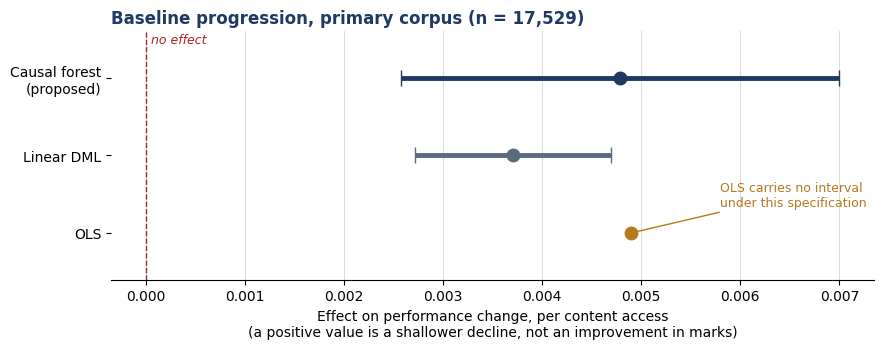

MATCH     Figure 3  Figure 3 rank correlation, held-out vs in-sample: yours -1   paper -1   (Figure 3 caption)


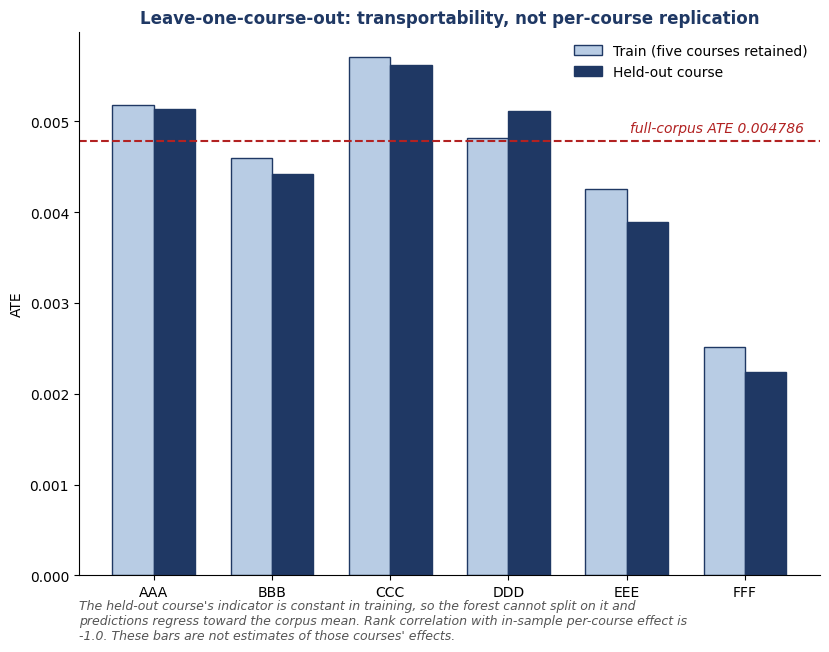

Saved figure2_baseline_progression.png and figure3_logo_transportability.png


In [12]:
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

NAVY, SLATE, OCHRE, RED = '#1F3864', '#5A6B7F', '#B7791F', '#B22222'

abl = pd.read_csv(f'{BASE}/ablation_results_v2.csv').set_index('config')
rows = [('Causal forest\n(proposed)', 'CausalForestDML honest=True (PROPOSED)', NAVY),
        ('Linear DML', 'Linear DML', SLATE),
        ('OLS', 'OLS', OCHRE)]
fig, ax = plt.subplots(figsize=(9, 3.6))
for k, (label, key, col) in enumerate(rows):
    yv = len(rows) - 1 - k
    r = abl.loc[key]
    if pd.notna(r['ci_lower']):
        ax.errorbar(r['ate'], yv, xerr=[[r['ate'] - r['ci_lower']], [r['ci_upper'] - r['ate']]],
                    fmt='o', color=col, ms=9, lw=3.5, capsize=6)
    else:
        ax.plot(r['ate'], yv, 'o', color=col, ms=9)
        ax.annotate('OLS carries no interval\nunder this specification', (r['ate'], yv),
                    xytext=(r['ate'] + 0.0009, yv + 0.35), color=col, fontsize=9,
                    arrowprops=dict(arrowstyle='-', color=col))
ax.axvline(0, ls='--', color=RED, lw=1)
ax.text(0.00005, len(rows) - 0.55, 'no effect', color=RED, fontsize=9, style='italic')
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows][::-1])
ax.set_ylim(-0.6, len(rows) - 0.4)
ax.set_xlabel('Effect on performance change, per content access\n(a positive value is a shallower decline, not an improvement in marks)')
ax.set_title(f'Baseline progression, primary corpus (n = {len(full):,})', loc='left', fontweight='bold', color=NAVY)
ax.grid(axis='x', color='#DDDDDD')
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(f'{BASE}/figure2_baseline_progression.png', dpi=300, bbox_inches='tight')
plt.show()

logo = pd.read_csv(f'{BASE}/logo_cv_results_v2.csv').set_index('held_out_module').sort_index()
insample = full.groupby('code_module')['cate'].mean().reindex(logo.index)
rho = spearmanr(insample, logo['ate_heldout_module']).correlation
check('Figure 3', 'Figure 3 rank correlation, held-out vs in-sample', rho, -1.0, 1e-9, 'Figure 3 caption')

fig, ax = plt.subplots(figsize=(8.4, 6.2))
x = np.arange(len(logo))
ax.bar(x - 0.175, logo['ate_train_modules'], 0.35, color='#B8CCE4', edgecolor=NAVY, label='Train (five courses retained)')
ax.bar(x + 0.175, logo['ate_heldout_module'], 0.35, color=NAVY, edgecolor=NAVY, label='Held-out course')
ax.axhline(ate, ls='--', color=RED, lw=1.5)
ax.text(len(logo) - 0.5, ate + 0.0001, f'full-corpus ATE {ate:.6f}', color=RED, ha='right', style='italic')
ax.set_xticks(x)
ax.set_xticklabels(logo.index)
ax.set_ylabel('ATE')
ax.set_title('Leave-one-course-out: transportability, not per-course replication', fontweight='bold', color=NAVY)
ax.legend(frameon=False, loc='upper right')
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
fig.text(0.1, -0.04, "The held-out course's indicator is constant in training, so the forest cannot split on it and\n"
         f"predictions regress toward the corpus mean. Rank correlation with in-sample per-course effect is\n"
         f"{rho:.1f}. These bars are not estimates of those courses' effects.", fontsize=9, color='#555555', style='italic')
fig.tight_layout()
fig.savefig(f'{BASE}/figure3_logo_transportability.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved figure2_baseline_progression.png and figure3_logo_transportability.png')

### B9 · Figure 1 with the corrected note
Redraws the causal graph (Figure 1). The partial R² labels come from B3 and the sensitivity note comes from `sensitivity_sd_units.csv` (05b cell 11), so no number in the figure is typed by hand. The three checks back the §5.8 sentences.

estimate reaches zero between k = 0.125 and 0.15
interval first covers zero between k = 0.09 and 0.1
whole interval below zero from k = 0.3
MATCH     §5.8  estimate reaches zero: lower k: yours 0.125   paper 0.125   (§5.8, §6.6, Figure 1)
MATCH     §5.8  estimate reaches zero: upper k: yours 0.15   paper 0.15   (§5.8, §6.6, Figure 1)
MATCH     §5.8  interval covers zero: lower k: yours 0.09   paper 0.09   (§5.8)
MATCH     §5.8  interval covers zero: upper k: yours 0.1   paper 0.1   (§5.8)
MATCH     §5.8  whole interval below zero from k: yours 0.3   paper 0.3   (§5.8)


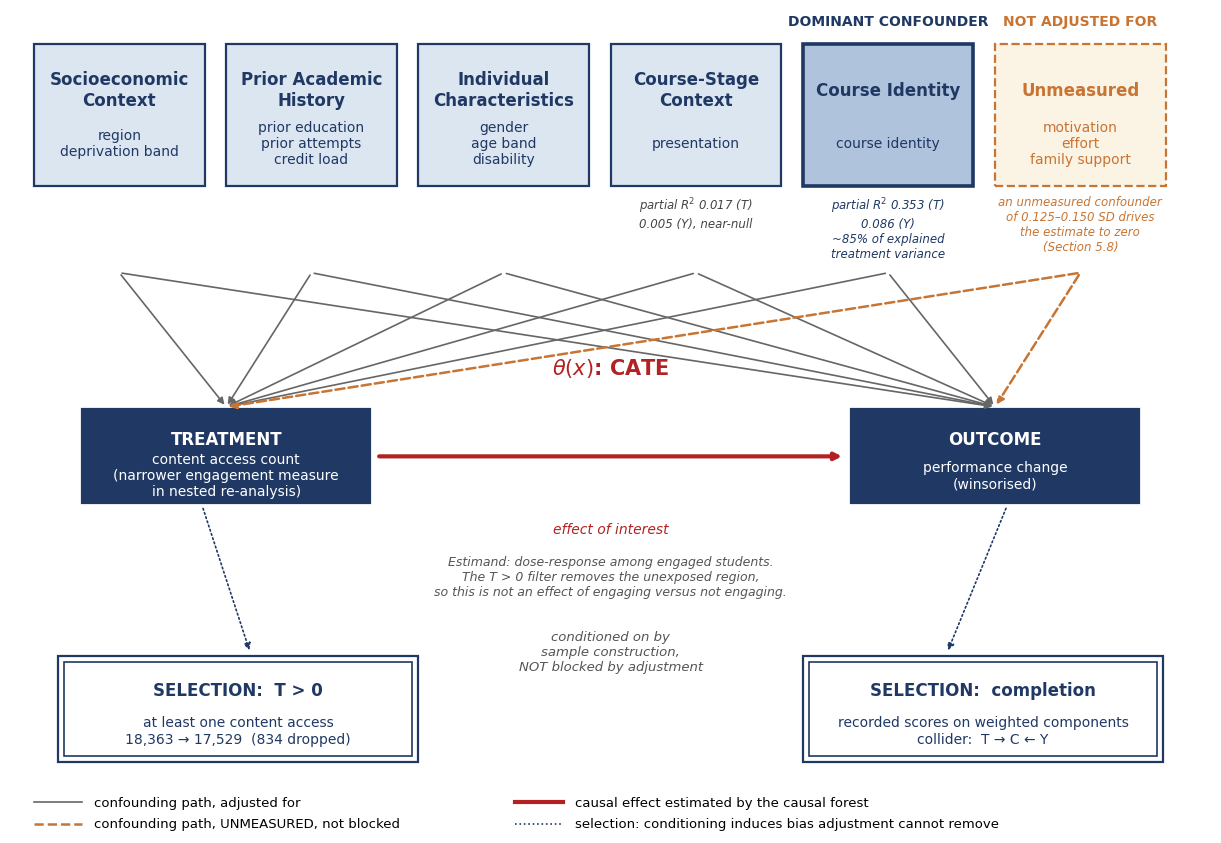

Saved dag.png (Figure 1)


In [13]:
from matplotlib.patches import FancyBboxPatch

sens = pd.read_csv(f'{BASE}/sensitivity_sd_units.csv').sort_values('k')
def first_k(mask):
    return float(sens.loc[mask, 'k'].min())
def last_k_before(k_first):
    return float(sens.loc[sens['k'] < k_first, 'k'].max())
k_est0 = first_k(sens['ate_k'] <= 0)
k_ci0 = first_k(sens['ci_low'] <= 0)
k_all_below = first_k(sens['ci_high'] < 0)
est_band = (last_k_before(k_est0), k_est0)
ci_band = (last_k_before(k_ci0), k_ci0)
print(f'estimate reaches zero between k = {est_band[0]} and {est_band[1]}')
print(f'interval first covers zero between k = {ci_band[0]} and {ci_band[1]}')
print(f'whole interval below zero from k = {k_all_below}')
check('§5.8', 'estimate reaches zero: lower k', est_band[0], 0.125, 1e-9, '§5.8, §6.6, Figure 1')
check('§5.8', 'estimate reaches zero: upper k', est_band[1], 0.150, 1e-9, '§5.8, §6.6, Figure 1')
check('§5.8', 'interval covers zero: lower k', ci_band[0], 0.090, 1e-9, '§5.8')
check('§5.8', 'interval covers zero: upper k', ci_band[1], 0.100, 1e-9, '§5.8')
check('§5.8', 'whole interval below zero from k', k_all_below, 0.300, 1e-9, '§5.8')

P = lambda b, t: g(b, t, 'partial_R2')
share_T = g('Course identity', 'T', 'share_drop')

fig, ax = plt.subplots(figsize=(15.5, 10.7))
ax.set_xlim(0, 100); ax.set_ylim(0, 70); ax.axis('off')
def box(x, y, w, h, title, body, fc='#DCE6F1', ec=NAVY, lw=1.6, ls='-', tc=NAVY, double=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='square,pad=0', fc=fc, ec=ec, lw=lw, ls=ls))
    if double:
        ax.add_patch(FancyBboxPatch((x + 0.5, y + 0.5), w - 1, h - 1, boxstyle='square,pad=0', fc='none', ec=ec, lw=1.2))
    ax.text(x + w / 2, y + h * 0.68, title, ha='center', va='center', fontsize=12, fontweight='bold', color=tc)
    ax.text(x + w / 2, y + h * 0.30, body, ha='center', va='center', fontsize=10, color=tc)

tops = [('Socioeconomic\nContext', 'region\ndeprivation band'),
        ('Prior Academic\nHistory', 'prior education\nprior attempts\ncredit load'),
        ('Individual\nCharacteristics', 'gender\nage band\ndisability'),
        ('Course-Stage\nContext', 'presentation'),
        ('Course Identity', 'course identity'),
        ('Unmeasured', 'motivation\neffort\nfamily support')]
W, H, Y0 = 14.2, 12, 55
xs = [2 + i * 16 for i in range(6)]
for i, (t, b) in enumerate(tops):
    if i == 5:
        box(xs[i], Y0, W, H, t, b, fc='#FBF3E4', ec='#C87533', ls='--', tc='#C87533')
    elif i == 4:
        box(xs[i], Y0, W, H, t, b, fc='#AFC3DC', lw=2.6)
    else:
        box(xs[i], Y0, W, H, t, b)
ax.text(xs[4] + W / 2, 68.6, 'DOMINANT CONFOUNDER', ha='center', fontsize=10, fontweight='bold', color=NAVY)
ax.text(xs[5] + W / 2, 68.6, 'NOT ADJUSTED FOR', ha='center', fontsize=10, fontweight='bold', color='#C87533')
ax.text(xs[3] + W / 2, 54.2, f"partial R$^2$ {P('Course-stage context', 'T'):.3f} (T)\n{P('Course-stage context', 'Y'):.3f} (Y), near-null",
        ha='center', va='top', fontsize=8.5, style='italic', color='#444444')
ax.text(xs[4] + W / 2, 54.2, f"partial R$^2$ {P('Course identity', 'T'):.3f} (T)\n{P('Course identity', 'Y'):.3f} (Y)\n"
        f"~{share_T:.0%} of explained\ntreatment variance", ha='center', va='top', fontsize=8.5, style='italic', color=NAVY)
ax.text(xs[5] + W / 2, 54.2, f"an unmeasured confounder\nof {est_band[0]:.3f}–{est_band[1]:.3f} SD drives\nthe estimate to zero\n(Section 5.8)",
        ha='center', va='top', fontsize=8.5, style='italic', color='#C87533')

TX, TY, OX, OY = 18, 36, 82, 36
box(6, 28, 24, 8, 'TREATMENT', 'content access count\n(narrower engagement measure\nin nested re-analysis)', fc=NAVY, tc='white')
box(70, 28, 24, 8, 'OUTCOME', 'performance change\n(winsorised)', fc=NAVY, tc='white')
for i in range(6):
    sx = xs[i] + W / 2
    style = dict(arrowstyle='-|>', color='#C87533', lw=1.8, ls='--') if i == 5 else dict(arrowstyle='-|>', color='#666666', lw=1.2)
    for tx in (TX, OX):
        ax.annotate('', xy=(tx, TY + 0.2), xytext=(sx, 47.6), arrowprops=style)
ax.annotate('', xy=(69.5, 32), xytext=(30.5, 32), arrowprops=dict(arrowstyle='-|>', color=RED, lw=3))
ax.text(50, 39, r'$\theta(x)$: CATE', ha='center', fontsize=15, fontweight='bold', color=RED)
ax.text(50, 25.5, 'effect of interest', ha='center', fontsize=10, style='italic', color=RED)

box(4, 6, 30, 9, 'SELECTION:  T > 0', 'at least one content access\n18,363 → 17,529  (834 dropped)', fc='white', double=True)
box(66, 6, 30, 9, 'SELECTION:  completion', 'recorded scores on weighted components\ncollider:  T → C ← Y', fc='white', double=True)
ax.annotate('', xy=(20, 15.3), xytext=(16, 27.8), arrowprops=dict(arrowstyle='-|>', color=NAVY, lw=1.2, ls=':'))
ax.annotate('', xy=(78, 15.3), xytext=(83, 27.8), arrowprops=dict(arrowstyle='-|>', color=NAVY, lw=1.2, ls=':'))
ax.text(50, 17.2, 'conditioned on by\nsample construction,\nNOT blocked by adjustment', ha='center', va='top', fontsize=9.5, style='italic', color='#555555')
ax.plot([2, 6], [2.6, 2.6], color='#666666', lw=1.2); ax.text(7, 2.6, 'confounding path, adjusted for', va='center', fontsize=9.5)
ax.plot([2, 6], [0.8, 0.8], color='#C87533', lw=1.8, ls='--'); ax.text(7, 0.8, 'confounding path, UNMEASURED, not blocked', va='center', fontsize=9.5)
ax.plot([42, 46], [2.6, 2.6], color=RED, lw=3); ax.text(47, 2.6, 'causal effect estimated by the causal forest', va='center', fontsize=9.5)
ax.plot([42, 46], [0.8, 0.8], color=NAVY, lw=1.2, ls=':'); ax.text(47, 0.8, 'selection: conditioning induces bias adjustment cannot remove', va='center', fontsize=9.5)
ax.text(50, 23.6, 'Estimand: dose-response among engaged students.\nThe T > 0 filter removes the unexposed region,\nso this is not an effect of engaging versus not engaging.',
        ha='center', va='top', fontsize=9, style='italic', color='#555555')
fig.savefig(f'{BASE}/03_causal_structure/dag.png' if os.path.isdir(f'{BASE}/03_causal_structure') else f'{BASE}/dag.png',
            dpi=200, bbox_inches='tight')
plt.show()
print('Saved dag.png (Figure 1)')

### B11 · Analytic and bootstrap standard errors
Paper: §5.8 analytic standard error 0.001128, bootstrap SD 0.000373, ratio 3.02. The analytic standard error is implied by the canonical forest's 95% interval. The bootstrap SD comes from the 100 resampling refits in `05b_refutation.ipynb`.

In [14]:
# B11  Analytic vs bootstrap standard error (§5.8)
abl = pd.read_csv(f'{BASE}/ablation_results_v2.csv').set_index('config')
r = abl.loc['CausalForestDML honest=True (PROPOSED)']
se_analytic = (r['ci_upper'] - r['ci_lower']) / (2 * 1.959964)
boot = json.load(open(f'{BASE}/refutation_checkpoints/A_bootstrap.json'))
sd_boot = float(boot['bootstrap_sd'])
print(f'analytic SE {se_analytic:.6f}   bootstrap SD {sd_boot:.6f}   ratio {se_analytic / sd_boot:.2f}')
check('§5.8', 'analytic SE implied by the forest interval', se_analytic, 0.001128, 5e-7, '§5.8')
check('§5.8', 'bootstrap SD', sd_boot, 0.000373, 5e-7, '§5.8')
check('§5.8', 'analytic SE / bootstrap SD', se_analytic / sd_boot, 3.02, 0.005, '§5.8')

analytic SE 0.001128   bootstrap SD 0.000373   ratio 3.02
MATCH     §5.8  analytic SE implied by the forest interval: yours 0.00112771   paper 0.001128   (§5.8)
MATCH     §5.8  bootstrap SD: yours 0.000373093   paper 0.000373   (§5.8)
MATCH     §5.8  analytic SE / bootstrap SD: yours 3.02258   paper 3.02   (§5.8)


True

### B10 · Environment, pins and CHECK SUMMARY
Prints a PIN? line for any package whose runtime version differs from requirements.txt, then the CHECK SUMMARY.

In [15]:
import sys
import importlib.metadata as md
print(f'python {sys.version.split()[0]}')
for line in open(f'{BASE}/requirements.txt'):
    line = line.strip()
    if '==' not in line:
        continue
    pkg, pin = line.split('==')
    try:
        have = md.version(pkg)
    except md.PackageNotFoundError:
        have = 'not installed'
    print(f"{'OK  ' if have == pin else 'PIN?'}  {pkg:14} requirements {pin:9} this runtime {have}")

summary = pd.DataFrame(CHECKS)
summary.to_csv(f'{BASE}/reported_numbers_check.csv', index=False)
print('\n' + '=' * 78 + '\nCHECK SUMMARY\n' + '=' * 78)
print(summary[['item', 'what', 'your_value', 'paper', 'status', 'where']].to_string(index=False))
bad = int((summary['status'] == 'MISMATCH').sum())
print(f'\n{len(summary)} checks, {bad} mismatch(es)')
print('ALL MATCH' if bad == 0 else 'Fix every MISMATCH before resubmitting: paper to your value, or the original cell here.')

python 3.13.16
OK    dowhy          requirements 0.14      this runtime 0.14
OK    econml         requirements 0.17.0    this runtime 0.17.0
OK    joblib         requirements 1.5.3     this runtime 1.5.3
OK    matplotlib     requirements 3.10.0    this runtime 3.10.0
OK    numpy          requirements 2.1.3     this runtime 2.1.3
OK    pandas         requirements 2.2.3     this runtime 2.2.3
OK    scikit-learn   requirements 1.6.1     this runtime 1.6.1
OK    scipy          requirements 1.16.3    this runtime 1.16.3
OK    shap           requirements 0.52.0    this runtime 0.52.0

CHECK SUMMARY
    item                                                        what    your_value         paper status                where
 Table 6                                          CCC 95% half-width  3.331721e-03  3.332000e-03  MATCH           §5.5, §6.4
 Table 6          Table 6 required n, smallest other-course estimate  1.214000e+03  1.214000e+03  MATCH              Table 6
 Table 6              Tab

### C1 · Engagement before the first graded assessment (§5.9)
Counts only content access **before the first graded assessment's due date**, so the treatment no longer overlaps the outcome window. It keeps the same 17,529 enrolments and the same forty columns, refits the canonical forest, and reports how many enrolments have no pre-assessment access. It needs the raw OULAD files in `raw/`. Set the switch to `False` to skip it. **Takes a few minutes.**

In [16]:
RUN_PRE_ASSESSMENT = True

if RUN_PRE_ASSESSMENT:
    raw = f'{BASE}/raw'
    sv = pd.read_csv(f'{raw}/studentVle.csv')
    vle = pd.read_csv(f'{raw}/vle.csv')
    asm = pd.read_csv(f'{raw}/assessments.csv')
    sa = pd.read_csv(f'{raw}/studentAssessment.csv')
    KEY = ['id_student', 'code_module', 'code_presentation']

    ma = sa.merge(asm[['id_assessment', 'code_module', 'code_presentation', 'date', 'weight']], on='id_assessment')
    valid = ma[(ma['is_banked'] == 0) & (ma['weight'] > 0)]
    first_due = valid.groupby(KEY)['date'].min().rename('first_due').reset_index()

    oc = sv.merge(vle[['id_site', 'code_module', 'code_presentation', 'activity_type']],
                  on=['id_site', 'code_module', 'code_presentation'], how='left')
    oc = oc[oc['activity_type'] == 'oucontent'].merge(first_due, on=KEY, how='inner')
    pre = oc[oc['date'] < oc['first_due']].groupby(KEY)['sum_click'].sum().rename('oucontent_pre').reset_index()

    full_pre = full[KEY].merge(pre, on=KEY, how='left').fillna({'oucontent_pre': 0})
    assert len(full_pre) == len(full) and (full_pre[KEY].values == full[KEY].values).all(), 'row order changed'
    T_pre = full_pre['oucontent_pre'].to_numpy(dtype=float)
    print(f'pre-assessment access: zero for {(T_pre == 0).sum():,} of {len(T_pre):,}   '
          f'median {np.median(T_pre):.0f}   SD {T_pre.std(ddof=1):.2f}   share of all access {T_pre.sum() / T.sum():.1%}')

    cf_pre = make_cf()
    cf_pre.fit(Y, T_pre, X=X)
    a_pre = float(cf_pre.ate(X))
    lo_p, hi_p = [float(np.ravel(v)[0]) for v in cf_pre.ate_interval(X, alpha=0.05)]
    per_sd_pre = a_pre * T_pre.std(ddof=1)
    per_sd_main = ate * T.std(ddof=1)
    print(f'restricted ATE {a_pre:.6f}   95% CI [{lo_p:.6f}, {hi_p:.6f}]')
    print(f'per SD of restricted engagement {per_sd_pre:.4f} marks   vs whole-presentation {per_sd_main:.4f} marks   '
          f'ratio {per_sd_pre / per_sd_main:.1%}')
    pd.DataFrame([{'ate': a_pre, 'ci_low': lo_p, 'ci_high': hi_p, 'sd_T_pre': T_pre.std(ddof=1),
                   'per_sd': per_sd_pre, 'per_sd_main': per_sd_main,
                   'n_zero': int((T_pre == 0).sum())}]).to_csv(f'{BASE}/pre_assessment_restriction.csv', index=False)
else:
    print('Pre-assessment restriction not run (switch is False).')

pre-assessment access: zero for 1,091 of 17,529   median 45   SD 119.68   share of all access 15.6%
restricted ATE 0.011485   95% CI [0.001118, 0.021853]
per SD of restricted engagement 1.3746 marks   vs whole-presentation 3.7417 marks   ratio 36.7%
